In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("spotify_dataset.csv")
df = df.drop_duplicates(subset=['track_name','artists'], keep='first').reset_index(drop=True)

feature_cols = ['acousticness', 'instrumentalness', 'speechiness','energy',
                 'loudness','tempo', 'danceability', 'valence', 
                 'liveness', 'key', 'mode', 'time_signature']

data = df[feature_cols].copy() # dataset copy with just numerical values

In [7]:
# Song/Artist Index Search
def find_song(query):
    return df[df['track_name'].str.contains(query, case=False) | 
              df['artists'].str.contains(query, case=False)][['track_name', 'artists']]

find_song("Zeppelin")

,track_name,artists
37881,Immigrant Song - Remaster,Led Zeppelin
37884,Stairway to Heaven - Remaster,Led Zeppelin
37903,Whole Lotta Love - 1990 Remaster,Led Zeppelin
37935,Black Dog - Remaster,Led Zeppelin
37937,Kashmir - Remaster,Led Zeppelin
38020,Rock and Roll - Remaster,Led Zeppelin
38023,Good Times Bad Times - 1993 Remaster,Led Zeppelin
38058,When the Levee Breaks - Remaster,Led Zeppelin
38064,Ramble On - 1990 Remaster,Led Zeppelin
38092,Tangerine - Remaster,Led Zeppelin


In [8]:
# Macro Genres for combining genres
macro = {
    # Classic and Hard Rock
    'rock': "Classic_Rock",
    'british': "Classic_Rock",
    'rock-n-roll': "Classic_Rock",
    'hard-rock': "Classic_Rock",
    'psych-rock': "Classic_Rock",
    'guitar': "Classic_Rock",
    
    # Alt 
    'punk': "Alt_indie",
    'alt-rock': "Alt_indie",
    'indie': "Alt_indie",
    'punk_rock': "Alt_indie",
    'grunge': "Alt_indie",
    'alternative': "Alt_indie",
    
    # Pop and synth
    'synth-pop': "Pop_synth",
    'pop': "Pop_synth",
    'power-pop': "Pop_synth",
    'piano': "Pop_synth",
    'power-pop': "Pop_synth",
    'indie-pop': "Pop_synth",
    'acoustic': "Pop_synth",
    'singer-songwriter': "Pop_synth",


    # World
    'indian': "World",
    'swedish': "World",
    'afrobeat': "World",
    'french': "World",
    'samba': "World",
    'turkish': "World",
    'latin': "World",
    'pagode': "World",
    'tango': "World",
    'world-music': "World",
    'latino': "World",
    'spanish': "World",
    'brazil': "World",
    'german': "World",
    'iranian': "World",
    'malay': "World",
    'reggaeton': "World",
    'k-pop': "World",
    'j-pop': "World",
    'j-rock': "World",
    'mandopop': "World",
    'cantopop': "World",

    # Electronic
    'edm': 'Electronic', 
    'house': 'Electronic', 
    'techno': 'Electronic',
    'trance': 'Electronic', 
    'dubstep': 'Electronic', 
    'dance': 'Electronic',
    'deep-house': 'Electronic', 
    'electronic': 'Electronic', 
    'club': 'Electronic',
    'breakbeat': 'Electronic', 
    'drum-and-bass': 'Electronic', 
    'idm': 'Electronic',

    # Metal
    'metal': 'Metal',
    'heavy-metal': 'Metal', 
    'black-metal': 'Metal',
    'death-metal': 'Metal', 
    'metalcore': 'Metal', 
    'grindcore': 'Metal',

    # Jazz, blues, soul, r&b
    'jazz': 'JBSRNB', 'blues': "JBSRNB", 'soul': "JBSRNB",
    'r-n-b': "JBSRNB", 'funk': "JBSRNB", 'disco': "JBSRNB",

    # Country and folk
    'country': 'Country_Folk', 'folk': 'Country_Folk', 'bluegrass': 'Country_Folk',
    'honky-tonk': 'Country_Folk'
}
# anything not in this list becomes "other" - edit later for greater accuracy
df['macro'] = df['track_genre'].map(lambda x: macro.get(x, "Other"))

print("Macro Genre Distribution")
print(df['macro'].value_counts())




Macro Genre Distribution
macro
Other           36123
World           16161
Electronic       7957
Metal            4707
Pop_synth        4366
Classic_Rock     3817
Country_Folk     3119
JBSRNB           2999
Alt_indie        2095
Name: count, dtype: int64


In [9]:
# Feature Engineering - scaling, one-hot encoding, and weighting
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

macro_dummies = pd.get_dummies(df['macro'], prefix='macro')

macro_weighted = macro_dummies * 5.0


In [10]:
# Tensor creation
combined_data = np.hstack([scaled_data, macro_weighted])
X = torch.tensor(combined_data).float()

In [11]:
# Data loader 
dataset = TensorDataset(X)
dataloader = DataLoader(dataset, batch_size=64, shuffle= True) # batch size use powers of 2
print(f"Data shape check: {X.shape}")

Data shape check: torch.Size([81344, 21])


Autoencoder Setup

In [12]:
class SongAutoencoder(nn.Module):
    def __init__(self, input_dimension):
        super(SongAutoencoder, self).__init__()

        # Encoder - going to squeeze 12 to 16 to 12
        # expand to 16 to find correlations then map back to 12
        self.encoder = nn.Sequential(
            nn.Linear(input_dimension, 64),
            nn.ReLU(),
            nn.Linear(64, 12),
            nn.ReLU()
        )

        # Decoder - reconstructing 12 features from 4
        self.decoder = nn.Sequential(
            nn.Linear(12, 64),
            nn.ReLU(),
            nn.Linear(64, input_dimension)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [13]:
model = SongAutoencoder(X.shape[1])
print(model)

SongAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=21, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=12, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=12, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=21, bias=True)
  )
)


Training Loop

Epoch [30/30] complete. Error: 0.0036


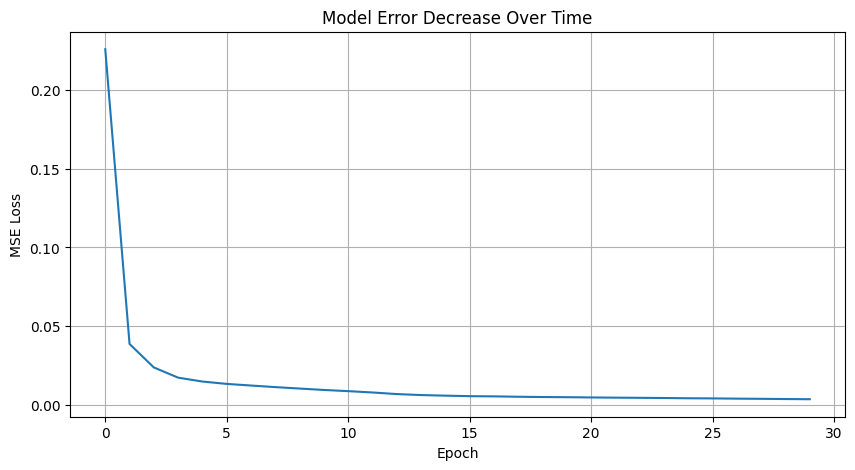

In [14]:
error_formula = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001) # why this learning rate

epochs = 30
losses = []

for epoch in range(epochs):
    error_this_epoch = 0

    for batch in dataloader:
        # get one batch of songs (64 each time)
        inputs = batch[0]

        # clear gradients (memory) from previous step
        optimizer.zero_grad()

        # forward pass: model tries reconstructing song "dna"
        outputs = model(inputs)
        
        # calculate error for this specific batch
        loss = error_formula(outputs, inputs)

        # backpropagation - calculate how much to change each weight
        loss.backward()

        # update and adjust weights
        optimizer.step()

        # accumulate error to list
        error_this_epoch += loss.item()

    avg_loss = error_this_epoch / len(dataloader)
    losses.append(avg_loss)

if (epoch + 1) % 5 == 0:
    print(f"Epoch [{epoch + 1}/{epochs}] complete. Error: {avg_loss:.4f}")

# Plot results
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.title("Model Error Decrease Over Time")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()


In [15]:
# Switch model out of training mode and into evaluation
model.eval()

# Generate latent representations (embeddings) - no gradient to save memory
with torch.no_grad():
    # pass entire X tensor through just encoder part
    latent_embeddings = model.encoder(X)

# Convert to Numpy array
embedding_matrix = latent_embeddings.numpy()

print(f"Embedding Matrix Shape: {embedding_matrix.shape}")
print(f"Latent vector for first song: \n{embedding_matrix[0]}")


Embedding Matrix Shape: (81344, 12)
Latent vector for first song: 
[ 4.446255   3.0800018  4.7316914  3.1067495 11.295984   3.3229706
  3.3430994 12.237573   9.6259165  2.2828977  2.1222994  1.326908 ]


In [16]:
# Recommender Function
from sklearn.metrics.pairwise import cosine_similarity

def get_recommendations(song_index, n_recs=5):
    # Get 4D Latent vector from base song
    # reshape into a 2d array
    query_vector = embedding_matrix[song_index].reshape(1, -1)

    # Calculate similarity score against all songs in df. 1.0 = identical, 0.0 = opposite
    similarity_scores = cosine_similarity(query_vector, embedding_matrix)[0]

    # Find indices of highest scores - use n+1 because base song will be perfect match
    top_indices = similarity_scores.argsort()[-(n_recs + 1):-1][::-1]

    # Display results using original uncopied dataframe:
    base_song = df.iloc[song_index]
    print(f"If you like: '{base_song["track_name"]}' by {base_song['artists']}")
    print("="*50)

    for rank, index in enumerate(top_indices, 1):
        match = df.iloc[index]
        score = similarity_scores[index]
        print(f"{rank}. {match['track_name']} | {match['artists']} ({score:.2%} Match)")
    
    return top_indices

top_indices = get_recommendations(38064)




If you like: 'Ramble On - 1990 Remaster' by Led Zeppelin
1. Seher Vakti | Barış Manço (99.98% Match)
2. Te Acordaras de Mí | Los Brios (99.96% Match)
3. Break on Through (To the Other Side) | The Doors (99.96% Match)
4. Muñequita (Roly Poly) | Enrique Guzman (99.95% Match)
5. Good Times Bad Times - 1993 Remaster | Led Zeppelin (99.94% Match)


In [17]:
# Check the genres of the results
df.iloc[[38064] + list(top_indices)][['track_name', 'artists', 'track_genre']]

,track_name,artists,track_genre
38064,Ramble On - 1990 Remaster,Led Zeppelin,hard-rock
63267,Seher Vakti,Barış Manço,psych-rock
65268,Te Acordaras de Mí,Los Brios,rock-n-roll
63090,Break on Through (To the Other Side),The Doors,psych-rock
65212,Muñequita (Roly Poly),Enrique Guzman,rock-n-roll
38023,Good Times Bad Times - 1993 Remaster,Led Zeppelin,hard-rock


In [18]:


# 1. Grab the indices from your last run
comparison_indices = [38064] + list(top_indices)

# 2. Create the vertical table
vibe_dashboard = df.iloc[comparison_indices].copy()
vibe_dashboard.set_index('track_name', inplace=True)

# 3. Transpose and highlight the "Leader" (the first column)
# We round to 3 decimals to keep it readable
vibe_dashboard = vibe_dashboard[feature_cols].T

print("Vibe Comparison Dashboard:")
display(vibe_dashboard.style.background_gradient(axis=1, cmap='viridis').format(precision=3))

Vibe Comparison Dashboard:


track_name,Ramble On - 1990 Remaster,Seher Vakti,Te Acordaras de Mí,Break on Through (To the Other Side),Muñequita (Roly Poly),Good Times Bad Times - 1993 Remaster
acousticness,0.072,0.009,0.059,0.200,0.335,0.038
instrumentalness,0.001,0.000,0.000,0.000,0.000,0.000
speechiness,0.034,0.032,0.033,0.047,0.032,0.095
energy,0.607,0.608,0.564,0.751,0.534,0.717
loudness,-11.367,-7.785,-11.127,-9.584,-9.032,-9.192
tempo,98.429,96.583,97.978,89.839,103.359,93.584
danceability,0.468,0.523,0.602,0.421,0.550,0.476
valence,0.886,0.766,0.725,0.789,0.944,0.753
liveness,0.225,0.206,0.151,0.170,0.236,0.082
key,9.000,9.000,9.000,9.000,8.000,9.000


Song Search Function within dataframe with duplicates removed

Genre Lookup

In [19]:
def show_unique_genres(dataframe):
    unique_genres = sorted(dataframe['track_genre'].unique())

    print(f"Total Unique Labels: {len(unique_genres)}")
    
    # print in grid w/ 5 columns
    for i in range(0, len(unique_genres), 5):
        print(" | ".join(f"{g:<20}" for g in unique_genres[i:i+5]))

show_unique_genres(df)

Total Unique Labels: 113
acoustic             | afrobeat             | alt-rock             | alternative          | ambient             
anime                | black-metal          | bluegrass            | blues                | brazil              
breakbeat            | british              | cantopop             | chicago-house        | children            
chill                | classical            | club                 | comedy               | country             
dance                | dancehall            | death-metal          | deep-house           | detroit-techno      
disco                | disney               | drum-and-bass        | dub                  | dubstep             
edm                  | electro              | electronic           | emo                  | folk                
forro                | french               | funk                 | garage               | german              
gospel               | goth                 | grindcore            | gr